# EDA orientado a decisiones Sistema de recomendación Instacart

**Data Analyst · Anastasia Ganderats · Sprint 1**

Este notebook tiene como objetivo **traducir los datos en decisiones**. Cada sección responde una pregunta del
recomendador y termina en un recuadro **→ Cómo seguir** con la decisión que habilita.

Como la base es **transaccional y sin demografía**, las dimensiones para cruzar no son edad o
género: son la **taxonomía de producto** (departamento/pasillo), el **tiempo** (día, hora,
recencia) y la **secuencia y co-ocurrencia** (qué va primero en el carrito y qué se compra junto).
El notebook explota esas tres.

1. ¿Sobre **qué tablas** y con qué **unidad de análisis** trabajamos?
2. ¿**A quién** le recomendamos? → segmentos de usuario.
3. ¿**Qué** recomendamos? → popularidad y su sesgo.
4. ¿Qué revela la **categoría** (departamento)? → rutina vs. descubrimiento.
5. ¿Cómo es el **carrito**? → tamaño, diversidad y posición.
6. ¿**Qué se compra junto**? → co-ocurrencia (market basket).
7. ¿**Cuándo**? → periodicidad y recencia.
8. **Calidad** que cambia el modelado.
9. **Síntesis "cómo seguir"**.

> **Reproducible y liviano.** Las agregaciones sobre los **32 millones** de filas del historial
> corren en **DuckDB** (SQL, sin cargar todo a RAM); pandas y matplotlib solo reciben resultados
> chicos. Requisito: `pip install duckdb pandas matplotlib`.


## 0. Setup y modelo de datos

In [1]:
%matplotlib inline
import os
from pathlib import Path

import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from matplotlib.colors import LinearSegmentedColormap

# --- Ubicar la carpeta de datos sin depender de la máquina -----------------
def _find_root(start):
    for c in [start, *start.parents]:
        if (c/"data"/"raw").exists() or (c/".git").exists():
            return c
    return start
ROOT = _find_root(Path.cwd().resolve())

_env = os.environ.get("INSTACART_DATA")
_cands = ([Path(_env)] if _env else []) + [ROOT/"data"/"raw", ROOT/"dataset", Path("dataset"), Path("data/raw")]
DS = next((p for p in _cands if (p / "orders.csv").exists()), None)
assert DS is not None, "No encuentro los CSV. Ponelos en data/raw/ (o dataset/), o exportá INSTACART_DATA."
print("Raíz del proyecto:", ROOT); print("Datos en:", DS.resolve())

FIG = ROOT/"reports"/"figures"; FIG.mkdir(parents=True, exist_ok=True)

# --- DuckDB: vistas sobre los CSV (no cargan a RAM) ------------------------
con = duckdb.connect()
con.execute("PRAGMA threads=2; PRAGMA memory_limit='2.5GB'; PRAGMA disable_progress_bar;")
for name, file in [("orders","orders.csv"),("prior","order_products__prior.csv"),
                   ("train","order_products__train.csv"),("products","products.csv"),
                   ("aisles","aisles.csv"),("departments","departments.csv")]:
    con.execute(f"CREATE VIEW {name} AS SELECT * FROM read_csv_auto('{DS/file}')")

def sql(q):
    """Devuelve un DataFrame a partir de SQL sobre las vistas DuckDB."""
    return con.execute(q).fetchdf()

print("Vistas creadas:", [r[0] for r in con.execute("SHOW TABLES").fetchall()])

Raíz del proyecto: C:\dev\instacart-recommender
Datos en: C:\dev\instacart-recommender\data\raw
Vistas creadas: ['aisles', 'departments', 'orders', 'prior', 'products', 'train']


In [2]:
# --- Paleta: solo azul / blanco / rojo (identidad UC). Nada de gris. -------
AZUL, AZUL_OSC, AZUL_MED, AZUL_CLARO = "#12408f", "#0a2a5e", "#2e67c4", "#a9c7ea"
ROJO = "#e4002b"
TINTA, TINTA2 = "#0a2340", "#39568c"          # texto: navy y azul apagado
GRILLA, EJE = "#e3ebf6", "#c2d6ef"            # grilla y ejes en azul muy claro
AZULES = ["#e8eff9","#cfe0f5","#a9c7ea","#7ba7dd","#4f84cc","#2e67c4","#1b4fa0","#123f86","#0a2a5e"]
CMAP = LinearSegmentedColormap.from_list("azules_uc", AZULES)

plt.rcParams.update({
    "figure.facecolor":"white","axes.facecolor":"white","savefig.facecolor":"white",
    "font.size":10, "figure.dpi":110, "axes.prop_cycle":plt.cycler(color=[AZUL,ROJO,AZUL_MED,AZUL_CLARO]),
})

def ejes(ax, titulo="", sub="", xlab="", ylab="", grid="y"):
    for s in ("top","right"): ax.spines[s].set_visible(False)
    for s in ("left","bottom"): ax.spines[s].set_color(EJE)
    ax.tick_params(colors=TINTA2, length=0, labelsize=9)
    if grid: ax.grid(axis=grid, color=GRILLA, linewidth=0.9); ax.set_axisbelow(True)
    if xlab: ax.set_xlabel(xlab, color=TINTA2, fontsize=9.5)
    if ylab: ax.set_ylabel(ylab, color=TINTA2, fontsize=9.5)
    if titulo: ax.set_title(titulo, color=TINTA, fontsize=12.5, fontweight="bold",
                            loc="left", pad=18 if sub else 10)
    if sub: ax.text(0, 1.015, sub, transform=ax.transAxes, color=TINTA2, fontsize=9.3, va="bottom")
    return ax

def miles(x, pos=None):
    if abs(x) >= 1e6: return f"{x/1e6:.1f}M"
    if abs(x) >= 1e3: return f"{x/1e3:.0f}k"
    return f"{x:.0f}"

def pct(x, pos=None): return f"{x:.0%}"

def guardar(fig, nombre):
    fig.savefig(FIG / f"{nombre}.png", dpi=140, bbox_inches="tight")
    print("figura →", FIG / f"{nombre}.png")

### Modelo de datos: 6 tablas, 2 bisagras

Esquema en estrella simple. Todo cuelga de dos claves: **`order_id`** (une el contexto del pedido
con su contenido) y **`product_id`** (une el contenido con el catálogo legible).

```mermaid
erDiagram
    departments ||--o{ products : clasifica
    aisles      ||--o{ products : clasifica
    orders      ||--o{ order_products_prior : contiene
    orders      ||--o{ order_products_train : contiene
    products    ||--o{ order_products_prior : aparece_en
    products    ||--o{ order_products_train : aparece_en
    orders { int order_id PK
             int user_id
             string eval_set
             int order_number
             int order_dow
             int order_hour_of_day
             float days_since_prior_order }
    products { int product_id PK
               string product_name
               int aisle_id FK
               int department_id FK }
    order_products_prior { int order_id PK_FK
                           int product_id PK_FK
                           int add_to_cart_order
                           int reordered }
```


In [3]:
# Inventario de las 6 tablas: volumen, clave e interpretación de la granularidad
inv = pd.DataFrame([
 ["orders",              sql("SELECT COUNT(*) n FROM orders")["n"][0],       "order_id (PK)",
  "user_id, eval_set, order_number, order_dow, order_hour_of_day, days_since_prior_order",
  "1 fila = 1 pedido (sin su contenido)"],
 ["order_products__prior", sql("SELECT COUNT(*) n FROM prior")["n"][0],      "order_id+product_id",
  "order_id→orders, product_id→products",  "1 fila = 1 producto dentro de un pedido del HISTORIAL"],
 ["order_products__train", sql("SELECT COUNT(*) n FROM train")["n"][0],      "order_id+product_id",
  "order_id→orders, product_id→products",  "1 fila = 1 producto de la ÚLTIMA orden (target de train)"],
 ["products",            sql("SELECT COUNT(*) n FROM products")["n"][0],     "product_id (PK)",
  "aisle_id→aisles, department_id→departments", "1 fila = 1 producto del catálogo"],
 ["aisles",              sql("SELECT COUNT(*) n FROM aisles")["n"][0],       "aisle_id (PK)", "—",
  "1 fila = 1 pasillo"],
 ["departments",         sql("SELECT COUNT(*) n FROM departments")["n"][0],  "department_id (PK)", "—",
  "1 fila = 1 departamento"],
], columns=["tabla","filas","clave_primaria","claves_foraneas","granularidad (1 fila = ...)"])
inv

,tabla,filas,clave_primaria,claves_foraneas,granularidad (1 fila = ...)
0,orders,3421083,order_id (PK),"user_id, eval_set, order_number, order_dow, or...",1 fila = 1 pedido (sin su contenido)
1,order_products__prior,32434489,order_id+product_id,"order_id→orders, product_id→products",1 fila = 1 producto dentro de un pedido del HI...
2,order_products__train,1384617,order_id+product_id,"order_id→orders, product_id→products",1 fila = 1 producto de la ÚLTIMA orden (target...
3,products,49688,product_id (PK),"aisle_id→aisles, department_id→departments",1 fila = 1 producto del catálogo
4,aisles,134,aisle_id (PK),—,1 fila = 1 pasillo
5,departments,21,department_id (PK),—,1 fila = 1 departamento


## 1. Unidad de análisis y alcance

*Pregunta de la Daily 1: ¿qué tablas y qué es una interacción?*

,eval_set,pedidos,usuarios
0,prior,3214874,206209
1,train,131209,131209
2,test,75000,75000


figura → C:\dev\instacart-recommender\reports\figures\01_particiones.png


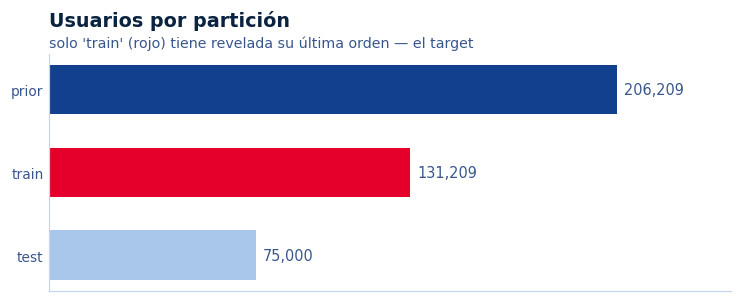

In [4]:
part = sql("""
  SELECT eval_set, COUNT(*) AS pedidos, COUNT(DISTINCT user_id) AS usuarios
  FROM orders GROUP BY eval_set ORDER BY pedidos DESC
""")
display(part)

fig, ax = plt.subplots(figsize=(8,2.8))
colores = {"prior":AZUL, "train":ROJO, "test":AZUL_CLARO}
ax.barh(part["eval_set"], part["usuarios"], color=[colores[e] for e in part["eval_set"]], height=.6)
for e,v in zip(part["eval_set"], part["usuarios"]):
    ax.text(v+2500, e, f"{v:,}", va="center", color=TINTA2, fontsize=9.5)
ax.set_xlim(0, part["usuarios"].max()*1.2); ax.set_xticks([]); ax.invert_yaxis()
ejes(ax, "Usuarios por partición", "solo 'train' (rojo) tiene revelada su última orden — el target", grid="x")
guardar(fig, "01_particiones"); plt.show()

In [5]:
chequeo = sql("""
  SELECT 'órdenes test con contenido en prior' AS control, COUNT(*) AS filas
  FROM (SELECT DISTINCT order_id FROM prior) p
  JOIN (SELECT order_id FROM orders WHERE eval_set='test') t USING(order_id)
  UNION ALL
  SELECT 'usuarios evaluables (train)', COUNT(*) FROM orders WHERE eval_set='train'
""")
chequeo

,control,filas
0,órdenes test con contenido en prior,0
1,usuarios evaluables (train),131209


> **→ Cómo seguir**
>
> - **Tablas:** `orders` + `order_products__prior` = **historial**; `products`, `aisles`,
>   `departments` = **catálogo**; `order_products__train` = **solo el target**.
> - **Unidad de análisis: la interacción `usuario × producto`** (de `orders ⋈ order_products__prior`).
> - **Evaluación:** los **75.000 usuarios de `test` no sirven para evaluar**. Entrenar con `prior`
>   (206.209) y **medir sobre la última orden de los 131.209 de `train`**. Nada de split aleatorio.


## 2. ¿A quién le recomendamos? Segmentos de usuario

In [6]:
# Perfil por usuario (una pasada por los 32M; se guarda agregado, 206k filas)
con.execute("""
CREATE OR REPLACE TABLE perfil AS
WITH po AS (SELECT o.user_id, p.order_id, p.product_id, p.reordered
            FROM prior p JOIN orders o USING(order_id))
SELECT user_id, COUNT(DISTINCT order_id) AS n_orders, COUNT(*) AS total_items,
       COUNT(DISTINCT product_id) AS distinct_products, AVG(reordered) AS reorder_rate
FROM po GROUP BY user_id
""")
# Etiqueta de segmento por profundidad de historial (se reutiliza en varias secciones)
con.execute("""CREATE OR REPLACE TABLE useg AS
  SELECT user_id, CASE WHEN n_orders<=5 THEN 'Nuevo' WHEN n_orders<=15 THEN 'Medio'
                       ELSE 'Heavy' END AS seg FROM perfil""")
perfil_df = con.execute("SELECT n_orders, distinct_products, reorder_rate FROM perfil").fetchdf()
print("usuarios perfilados:", len(perfil_df))
perfil_df.describe(percentiles=[.25,.5,.75,.9]).loc[["mean","25%","50%","75%","90%"]].round(2)

usuarios perfilados: 206209


,n_orders,distinct_products,reorder_rate
mean,15.59,64.54,0.43
25%,5.00,25.00,0.27
50%,9.00,48.00,0.43
75%,19.00,86.00,0.60
90%,37.00,139.00,0.72


,segmento,usuarios,pct,productos_distintos,tasa_recompra
0,Nuevo (≤5),59741,29.0,27.7,0.245
1,Medio (6–15),81172,39.4,52.8,0.415
2,Heavy (16+),65296,31.7,112.8,0.624


figura → C:\dev\instacart-recommender\reports\figures\02_segmentos.png


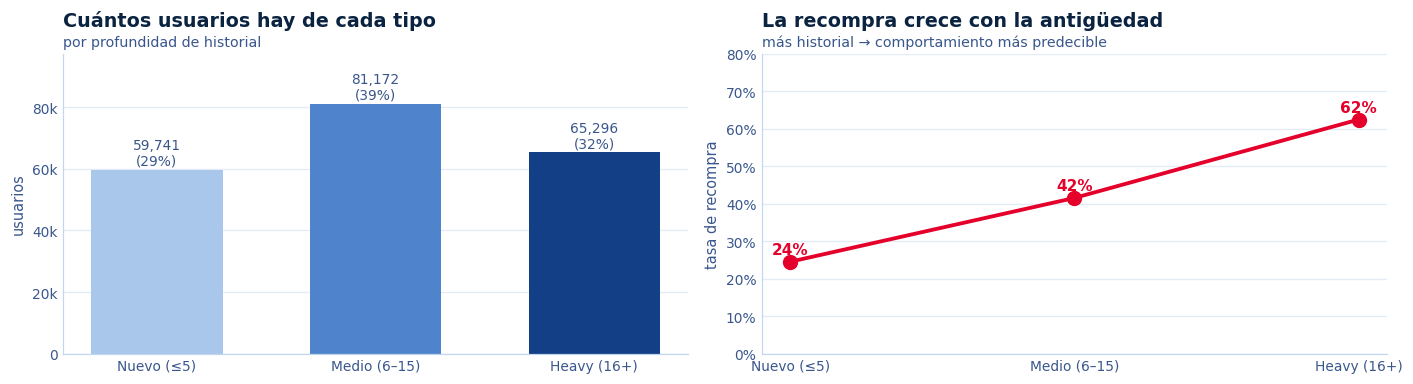

In [7]:
seg_depth = sql("""
  SELECT CASE WHEN n_orders<=5 THEN 'Nuevo (≤5)' WHEN n_orders<=15 THEN 'Medio (6–15)'
              ELSE 'Heavy (16+)' END AS segmento,
         COUNT(*) AS usuarios,
         ROUND(100.0*COUNT(*)/SUM(COUNT(*)) OVER (),1) AS pct,
         ROUND(AVG(distinct_products),1) AS productos_distintos,
         ROUND(AVG(reorder_rate),3) AS tasa_recompra
  FROM perfil GROUP BY 1""")
seg_depth["orden"] = seg_depth["segmento"].map({"Nuevo (≤5)":0,"Medio (6–15)":1,"Heavy (16+)":2})
seg_depth = seg_depth.sort_values("orden").drop(columns="orden").reset_index(drop=True)
display(seg_depth)

fig, axes = plt.subplots(1, 2, figsize=(13, 3.6))
ax = axes[0]
ax.bar(seg_depth["segmento"], seg_depth["usuarios"], color=[AZULES[2],AZULES[4],AZULES[7]], width=.6)
for i,(u,p) in enumerate(zip(seg_depth["usuarios"], seg_depth["pct"])):
    ax.text(i, u+1500, f"{u:,}\n({p:.0f}%)", ha="center", color=TINTA2, fontsize=9)
ax.set_ylim(0, seg_depth["usuarios"].max()*1.2)
ejes(ax, "Cuántos usuarios hay de cada tipo", "por profundidad de historial", ylab="usuarios")
ax.yaxis.set_major_formatter(FuncFormatter(miles))
ax = axes[1]
ax.plot(seg_depth["segmento"], seg_depth["tasa_recompra"], marker="o", color=ROJO, linewidth=2.5, markersize=9)
for i,v in enumerate(seg_depth["tasa_recompra"]):
    ax.text(i, v+.02, f"{v:.0%}", ha="center", color=ROJO, fontsize=10, fontweight="bold")
ax.set_ylim(0,.8)
ejes(ax, "La recompra crece con la antigüedad", "más historial → comportamiento más predecible",
     ylab="tasa de recompra")
ax.yaxis.set_major_formatter(FuncFormatter(pct))
guardar(fig, "02_segmentos"); plt.tight_layout(); plt.show()

> **→ Cómo seguir**
>
> Tres perfiles con estrategias distintas. **Heavy (32%)**, con **62% de recompra**, se modela
> repitiendo/priorizando lo que ya compran (recompra, colaborativo). **Nuevos (29%)**, con **24%**,
> son **cold-start**: manda popularidad + catálogo. La **tasa de recompra por usuario** y la
> **profundidad de historial** entran como features. Evaluar **por segmento**, no solo global.


## 3. ¿Qué recomendamos? Popularidad y su sesgo

50% de las compras se explican con 787 productos (1.6% del catálogo)
80% de las compras se explican con 4,538 productos (9.1% del catálogo)
90% de las compras se explican con 9,152 productos (18.4% del catálogo)

Recompra global (líneas prior): 59.0%
Productos nunca comprados (cold-start de ítem): 11
figura → C:\dev\instacart-recommender\reports\figures\03_popularidad.png


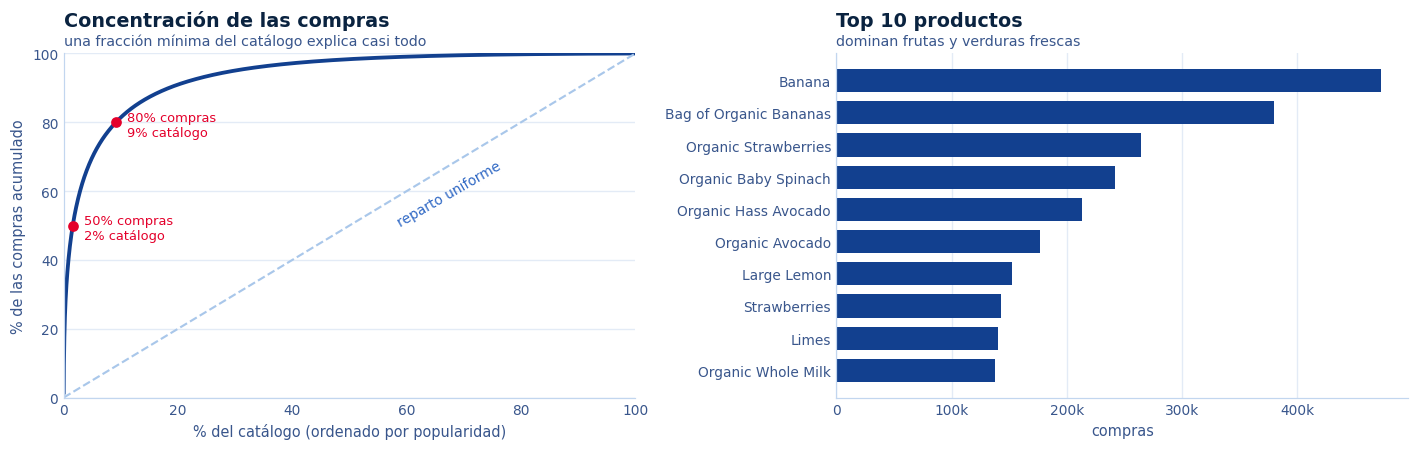

In [8]:
pop = sql("""SELECT p.product_id, pr.product_name, COUNT(*) AS compras, SUM(p.reordered) AS recompras
             FROM prior p JOIN products pr USING(product_id) GROUP BY 1,2 ORDER BY compras DESC""")
n_prod = int(sql("SELECT COUNT(*) n FROM products")["n"][0])
reorder_global = pop["recompras"].sum()/pop["compras"].sum()
nunca = n_prod - len(pop)
acum = pop["compras"].values.cumsum()/pop["compras"].sum()
share = np.arange(1, len(pop)+1)/n_prod
umbral = {u:(int(np.searchsorted(acum,u))+1) for u in (0.5,0.8,0.9)}
for u,n in umbral.items():
    print(f"{u:.0%} de las compras se explican con {n:,} productos ({n/n_prod:.1%} del catálogo)")
print(f"\nRecompra global (líneas prior): {reorder_global:.1%}")
print(f"Productos nunca comprados (cold-start de ítem): {nunca}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
ax = axes[0]
ax.plot(share*100, acum*100, color=AZUL, linewidth=2.5)
ax.plot([0,100],[0,100], color=AZUL_CLARO, linewidth=1.4, linestyle="--")
ax.text(58, 50, "reparto uniforme", color=AZUL_MED, fontsize=9, rotation=30)
for u in (0.5,0.8):
    n = umbral[u]; ax.plot(n/n_prod*100, u*100, "o", color=ROJO)
    ax.text(n/n_prod*100+2, u*100-4, f"{u:.0%} compras\n{n/n_prod:.0%} catálogo", color=ROJO, fontsize=8.5)
ax.set_xlim(0,100); ax.set_ylim(0,100)
ejes(ax, "Concentración de las compras", "una fracción mínima del catálogo explica casi todo",
     xlab="% del catálogo (ordenado por popularidad)", ylab="% de las compras acumulado")
ax = axes[1]
top = pop.head(10).iloc[::-1]
ax.barh(top["product_name"], top["compras"], color=AZUL, height=.72)
ax.xaxis.set_major_formatter(FuncFormatter(miles))
ejes(ax, "Top 10 productos", "dominan frutas y verduras frescas", xlab="compras", grid="x")
guardar(fig, "03_popularidad"); plt.tight_layout(); plt.show()

In [9]:
# ¿La popularidad es la misma en todos los segmentos? -> ¿sirve un único baseline?
tops = sql("""
  SELECT u.seg, pr.product_name, COUNT(*) c
  FROM prior p JOIN orders o USING(order_id) JOIN useg u ON o.user_id=u.user_id
  JOIN products pr ON p.product_id=pr.product_id
  WHERE u.seg IN ('Nuevo','Heavy') GROUP BY 1,2""")
top10 = lambda seg: tops[tops.seg==seg].nlargest(10,"c")["product_name"].tolist()
heavy, nuevo = top10("Heavy"), top10("Nuevo")
overlap = len(set(heavy)&set(nuevo))
print(f"Productos en común entre el top-10 de nuevos y el de heavy: {overlap} de 10")
pd.DataFrame({"Top-10 usuarios NUEVOS":nuevo, "Top-10 usuarios HEAVY":heavy})

Productos en común entre el top-10 de nuevos y el de heavy: 8 de 10


,Top-10 usuarios NUEVOS,Top-10 usuarios HEAVY
0,Banana,Banana
1,Bag of Organic Bananas,Bag of Organic Bananas
2,Organic Baby Spinach,Organic Strawberries
3,Organic Strawberries,Organic Baby Spinach
4,Organic Avocado,Organic Hass Avocado
5,Large Lemon,Organic Avocado
6,Organic Hass Avocado,Organic Whole Milk
7,Strawberries,Organic Raspberries
8,Limes,Large Lemon
9,Cucumber Kirby,Limes


> **→ Cómo seguir**
>
> **Sesgo de popularidad fuerte:** el **50%** de las compras = **~790 productos (1,6% del catálogo)**;
> el **80%** = **~9%**. Y el **top-10 de nuevos y heavy comparte 8/10** → el baseline de popularidad
> global va a ser **difícil de superar**; la personalización solo demuestra valor en la **cola**.
> **Baseline:** popularidad global + repetir la última orden. **Métrica:** `Recall@10` **+ cobertura
> de catálogo** por segmento. El ítem cold-start es marginal (11 productos); el problema es el
> **usuario nuevo**.


## 4. ¿Qué revela la categoría? Rutina vs. descubrimiento

*La taxonomía de producto es, en esta base, el reemplazo de la demografía: nos deja cruzar el
comportamiento por tipo de producto.*

,department,compras,pct_compras,reorder_rate
0,produce,9479291,29.2,0.649913
1,dairy eggs,5414016,16.7,0.669969
2,snacks,2887550,8.9,0.574180
3,beverages,2690129,8.3,0.653460
4,frozen,2236432,6.9,0.541885
5,pantry,1875577,5.8,0.346721
6,bakery,1176787,3.6,0.628141
7,canned goods,1068058,3.3,0.457405
8,deli,1051249,3.2,0.607719
9,dry goods pasta,866627,2.7,0.461076


figura → C:\dev\instacart-recommender\reports\figures\04_categorias.png


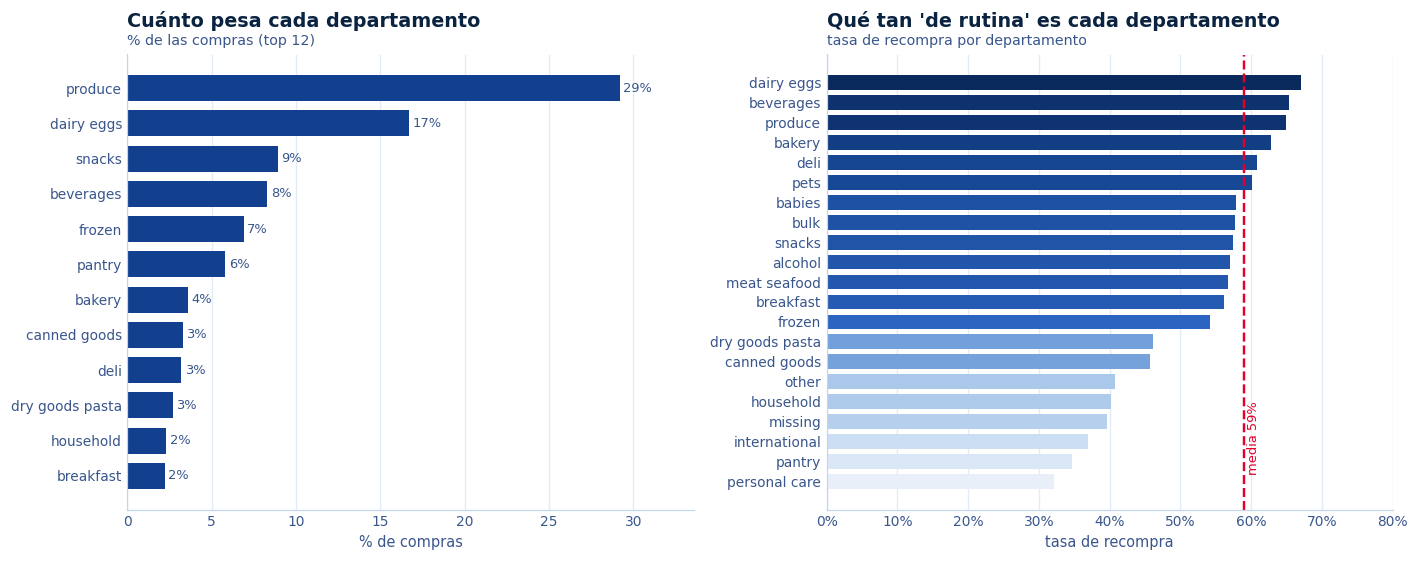

In [10]:
depto = sql("""
  SELECT d.department, COUNT(*) compras,
         ROUND(100.0*COUNT(*)/SUM(COUNT(*)) OVER(),1) pct_compras,
         AVG(p.reordered) reorder_rate
  FROM prior p JOIN products pr USING(product_id) JOIN departments d USING(department_id)
  GROUP BY 1 ORDER BY compras DESC""")
display(depto.head(10))

fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))
ax = axes[0]
t = depto.head(12).iloc[::-1]
ax.barh(t["department"], t["pct_compras"], color=AZUL, height=.74)
for d,v in zip(t["department"], t["pct_compras"]):
    ax.text(v+0.2, d, f"{v:.0f}%", va="center", color=TINTA2, fontsize=8.5)
ax.set_xlim(0, depto["pct_compras"].max()*1.15)
ejes(ax, "Cuánto pesa cada departamento", "% de las compras (top 12)", xlab="% de compras", grid="x")
ax = axes[1]
rr = depto.sort_values("reorder_rate")
cols = CMAP((rr["reorder_rate"]-rr["reorder_rate"].min())/(rr["reorder_rate"].max()-rr["reorder_rate"].min()))
ax.barh(rr["department"], rr["reorder_rate"], color=cols, height=.74)
ax.axvline(reorder_global, color=ROJO, linewidth=1.6, linestyle="--")
ax.text(reorder_global+0.005, 0.3, f"media {reorder_global:.0%}", color=ROJO, fontsize=8.5, rotation=90, va="bottom")
ax.set_xlim(0, .8)
ejes(ax, "Qué tan 'de rutina' es cada departamento", "tasa de recompra por departamento",
     xlab="tasa de recompra", grid="x")
ax.xaxis.set_major_formatter(FuncFormatter(pct))
guardar(fig, "04_categorias"); plt.tight_layout(); plt.show()

figura → C:\dev\instacart-recommender\reports\figures\04b_segmento_categoria.png


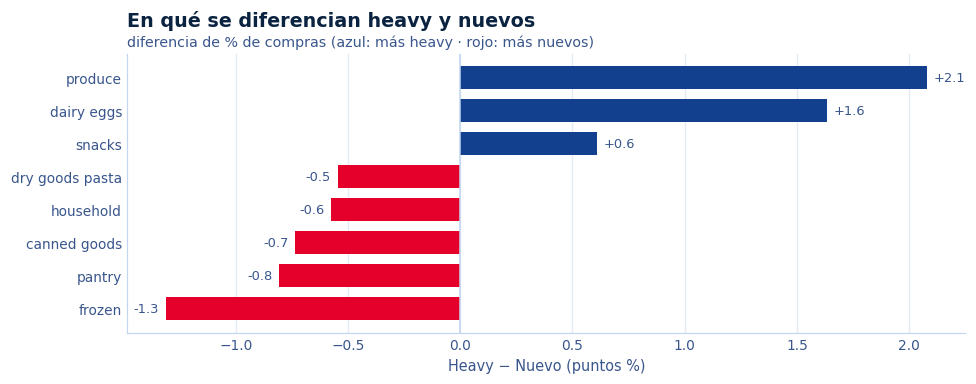

In [11]:
# ¿Cambian las categorías con la madurez del usuario? (heavy vs nuevo)
sd = sql("""SELECT u.seg, d.department, COUNT(*) c
   FROM prior p JOIN orders o USING(order_id) JOIN useg u USING(user_id)
   JOIN products pr ON p.product_id=pr.product_id JOIN departments d USING(department_id)
   WHERE u.seg IN ('Nuevo','Heavy') GROUP BY 1,2""")
piv = sd.pivot_table(index="department", columns="seg", values="c", fill_value=0)
piv = piv.div(piv.sum(axis=0), axis=1)*100
piv["dif"] = piv["Heavy"] - piv["Nuevo"]
top = piv.reindex(piv["dif"].abs().sort_values(ascending=False).index).head(8).sort_values("dif")

fig, ax = plt.subplots(figsize=(9, 3.6))
cols = [AZUL if v>0 else ROJO for v in top["dif"]]
ax.barh(top.index, top["dif"], color=cols, height=.7)
ax.axvline(0, color=EJE, linewidth=1)
for dep,v in zip(top.index, top["dif"]):
    ax.text(v+(0.03 if v>0 else -0.03), dep, f"{v:+.1f}", va="center",
            ha="left" if v>0 else "right", color=TINTA2, fontsize=8.5)
ejes(ax, "En qué se diferencian heavy y nuevos", "diferencia de % de compras (azul: más heavy · rojo: más nuevos)",
     xlab="Heavy − Nuevo (puntos %)", grid="x")
guardar(fig, "04b_segmento_categoria"); plt.tight_layout(); plt.show()

> **→ Cómo seguir**
>
> La recompra **varía muchísimo por departamento**: **produce (65%) y dairy eggs (67%)** son pura
> **rutina** y juntos son **~46% de las compras**; **pantry (35%), personal care (32%) y household
> (40%)** son **descubrimiento/one-off**. Decisión: el **departamento/pasillo es una feature de
> contenido** (clave para el cold-start del usuario nuevo) y sirve para **recomendaciones de rutina
> vs. de descubrimiento**. Además, a medida que el usuario madura **se vuelca a lo fresco** (heavy:
> +produce/+dairy; nuevos: +frozen/+pantry) → oportunidad de empujar frescos a los nuevos.


## 5. Anatomía del carrito

*Tamaño, diversidad y orden en que se arma.*

Carrito: mediana 8 ítems, 4 departamentos distintos
figura → C:\dev\instacart-recommender\reports\figures\05_carrito.png


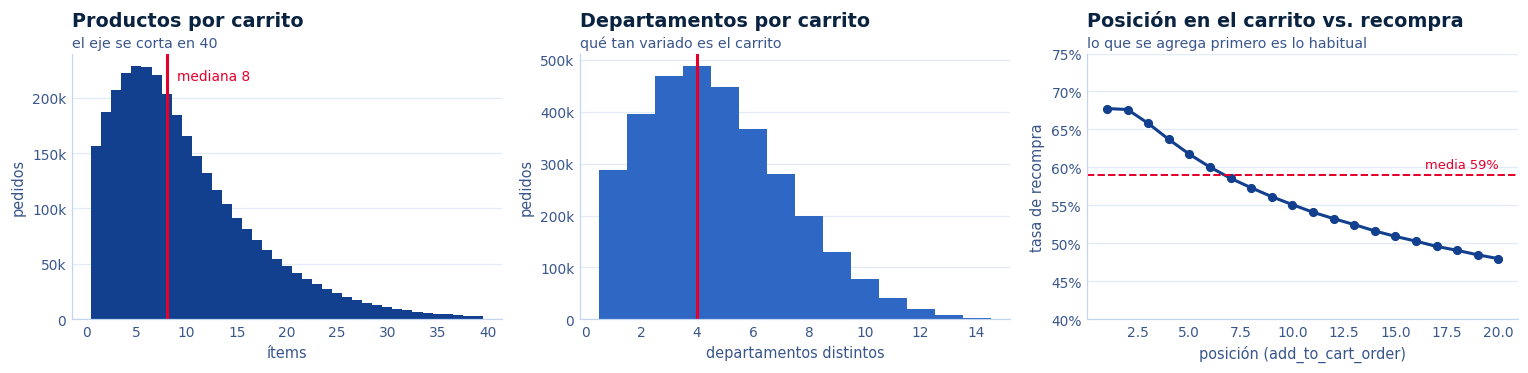

In [12]:
con.execute("""CREATE OR REPLACE TABLE bo AS
  SELECT p.order_id, COUNT(*) n_items, COUNT(DISTINCT pr.department_id) n_deptos
  FROM prior p JOIN products pr USING(product_id) GROUP BY p.order_id""")
bo = con.execute("SELECT n_items, n_deptos FROM bo").fetchdf()
atc = sql("""SELECT add_to_cart_order pos, AVG(reordered) reorder, COUNT(*) n
             FROM prior GROUP BY 1 HAVING n>5000 ORDER BY 1 LIMIT 20""")
print(f"Carrito: mediana {bo['n_items'].median():.0f} ítems, {bo['n_deptos'].median():.0f} departamentos distintos")

fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))
ax = axes[0]
ax.hist(bo["n_items"], bins=np.arange(1,41)-.5, color=AZUL, edgecolor="none")
ax.axvline(bo["n_items"].median(), color=ROJO, linewidth=2)
ax.text(bo["n_items"].median()+1, ax.get_ylim()[1]*.9, f"mediana {bo['n_items'].median():.0f}", color=ROJO, fontsize=9)
ejes(ax, "Productos por carrito", "el eje se corta en 40", xlab="ítems", ylab="pedidos")
ax.yaxis.set_major_formatter(FuncFormatter(miles))
ax = axes[1]
ax.hist(bo["n_deptos"], bins=np.arange(1,16)-.5, color=AZUL_MED, edgecolor="none")
ax.axvline(bo["n_deptos"].median(), color=ROJO, linewidth=2)
ejes(ax, "Departamentos por carrito", "qué tan variado es el carrito", xlab="departamentos distintos", ylab="pedidos")
ax.yaxis.set_major_formatter(FuncFormatter(miles))
ax = axes[2]
ax.plot(atc["pos"], atc["reorder"], marker="o", color=AZUL, linewidth=2, markersize=5)
ax.axhline(reorder_global, color=ROJO, linewidth=1.3, linestyle="--")
ax.text(atc["pos"].max(), reorder_global+.01, f"media {reorder_global:.0%}", color=ROJO, fontsize=8.5, ha="right")
ax.set_ylim(.4,.75)
ejes(ax, "Posición en el carrito vs. recompra", "lo que se agrega primero es lo habitual",
     xlab="posición (add_to_cart_order)", ylab="tasa de recompra")
ax.yaxis.set_major_formatter(FuncFormatter(pct))
guardar(fig, "05_carrito"); plt.tight_layout(); plt.show()

> **→ Cómo seguir**
>
> El carrito típico tiene **~8 ítems de ~5 departamentos** (variado, no monotema). Y la **posición en
> el carrito es señal**: lo que se agrega primero se recompra **68%**, cae a **48%** al final.
> Decisiones: **`add_to_cart_order` es feature** y, sobre todo, **el orden de las recomendaciones
> importa** (primero lo habitual); normalizar las features por **tamaño de carrito** para que las
> compras de abastecimiento no dominen.


## 6. ¿Qué se compra junto? Co-ocurrencia (market basket)

*La técnica más propia de un recomendador: aprender de los pares.*

figura → C:\dev\instacart-recommender\reports\figures\06_coocurrencia.png


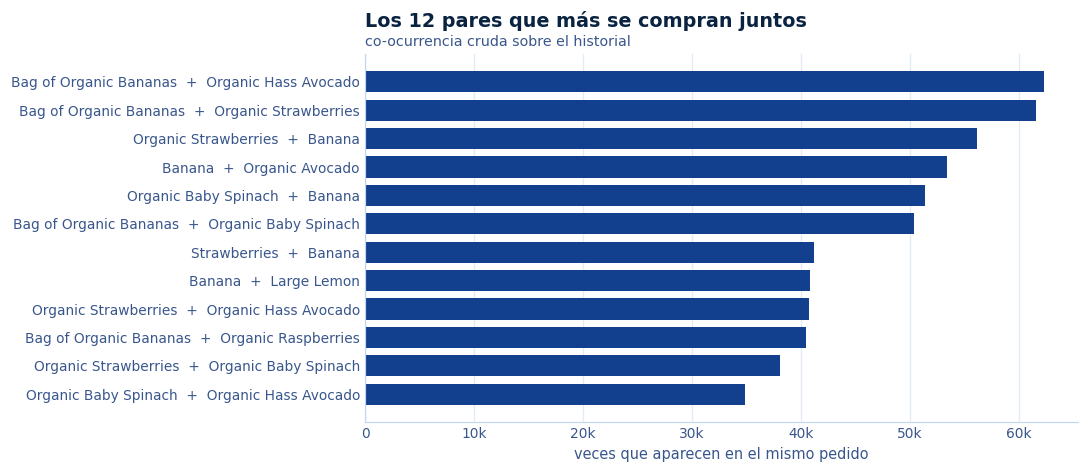

,par,juntos
0,Bag of Organic Bananas + Organic Hass Avocado,62341
1,Bag of Organic Bananas + Organic Strawberries,61628
2,Organic Strawberries + Banana,56156
3,Banana + Organic Avocado,53395
4,Organic Baby Spinach + Banana,51395
5,Bag of Organic Bananas + Organic Baby Spinach,50372
6,Strawberries + Banana,41232
7,Banana + Large Lemon,40880
8,Organic Strawberries + Organic Hass Avocado,40794
9,Bag of Organic Bananas + Organic Raspberries,40503


In [13]:
# Co-ocurrencia restringida a los 200 productos más comprados (para que sea liviano)
con.execute("""CREATE OR REPLACE TABLE b AS
   SELECT order_id, product_id FROM prior
   WHERE product_id IN (SELECT product_id FROM prior GROUP BY product_id ORDER BY COUNT(*) DESC LIMIT 200)""")
pares = sql("""
   SELECT n1.product_name || '  +  ' || n2.product_name AS par, COUNT(*) juntos
   FROM b x JOIN b y ON x.order_id=y.order_id AND x.product_id<y.product_id
   JOIN products n1 ON x.product_id=n1.product_id JOIN products n2 ON y.product_id=n2.product_id
   GROUP BY 1 ORDER BY juntos DESC LIMIT 12""")

fig, ax = plt.subplots(figsize=(10, 4.4))
t = pares.iloc[::-1]
ax.barh(t["par"], t["juntos"], color=AZUL, height=.75)
ax.xaxis.set_major_formatter(FuncFormatter(miles))
ejes(ax, "Los 12 pares que más se compran juntos", "co-ocurrencia cruda sobre el historial",
     xlab="veces que aparecen en el mismo pedido", grid="x")
guardar(fig, "06_coocurrencia"); plt.tight_layout(); plt.show()
pares

> **→ Cómo seguir**
>
> Todos los pares top son **frescos con frescos** (banana ancla casi todo). Ojo con la lectura: la
> co-ocurrencia **cruda está dominada por la popularidad** — la banana aparece con todo simplemente
> porque está en todos los carritos. Decisión de modelado: para que la co-ocurrencia sea útil hay que
> **normalizarla (lift / confianza)**, no usar el conteo crudo, o el modelo va a "recomendar banana"
> siempre. Aun así, confirma que **produce es la categoría ancla** y habilita un modelo de
> **co-ocurrencia / complementos** (una de las opciones de la Daily 3).


## 7. ¿Cuándo? Periodicidad y recencia

figura → C:\dev\instacart-recommender\reports\figures\07_dia_hora.png


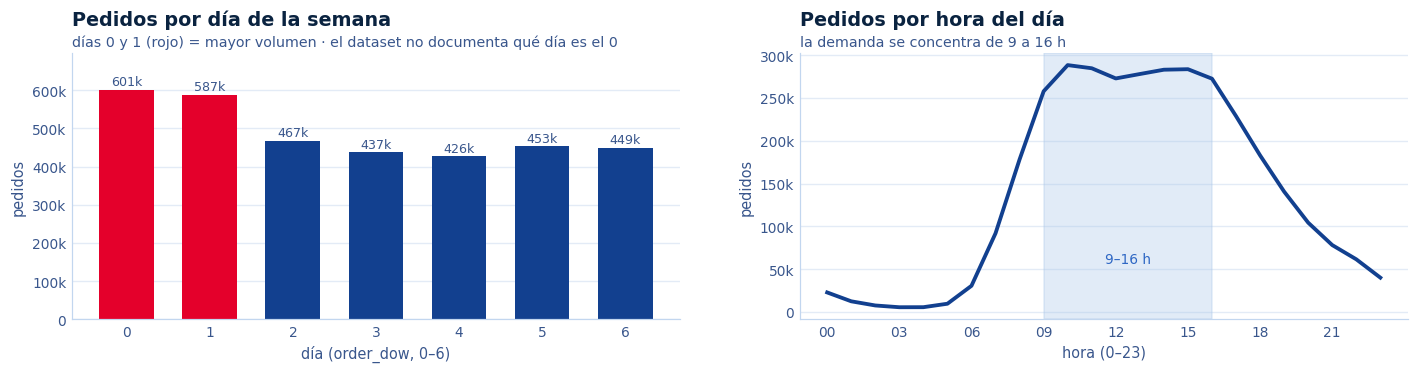

In [14]:
dow = sql("SELECT order_dow, COUNT(*) c FROM orders GROUP BY 1 ORDER BY 1")
hora = sql("SELECT order_hour_of_day h, COUNT(*) c FROM orders GROUP BY 1 ORDER BY 1")
picos = dow.nlargest(2, "c")["order_dow"].tolist()

fig, axes = plt.subplots(1, 2, figsize=(13, 3.5))
ax = axes[0]
cols = [ROJO if dd in picos else AZUL for dd in dow["order_dow"]]
ax.bar(dow["order_dow"], dow["c"], color=cols, width=.66)
for dd,c in zip(dow["order_dow"], dow["c"]):
    ax.text(dd, c+dow["c"].max()*.02, miles(c), ha="center", color=TINTA2, fontsize=8.3)
ax.set_ylim(0, dow["c"].max()*1.16); ax.set_xticks(range(7))
ejes(ax, "Pedidos por día de la semana",
     "días 0 y 1 (rojo) = mayor volumen · el dataset no documenta qué día es el 0",
     xlab="día (order_dow, 0–6)", ylab="pedidos")
ax.yaxis.set_major_formatter(FuncFormatter(miles))
ax = axes[1]
ax.plot(hora["h"], hora["c"], color=AZUL, linewidth=2.5)
ax.axvspan(9, 16, color=AZUL_CLARO, alpha=.35)
ax.text(12.5, hora["c"].max()*.2, "9–16 h", color=AZUL_MED, fontsize=9, ha="center")
ax.set_xticks(range(0,24,3))
ejes(ax, "Pedidos por hora del día", "la demanda se concentra de 9 a 16 h", xlab="hora (0–23)", ylab="pedidos")
ax.yaxis.set_major_formatter(FuncFormatter(miles))
guardar(fig, "07_dia_hora"); plt.tight_layout(); plt.show()

figura → C:\dev\instacart-recommender\reports\figures\08_recencia.png


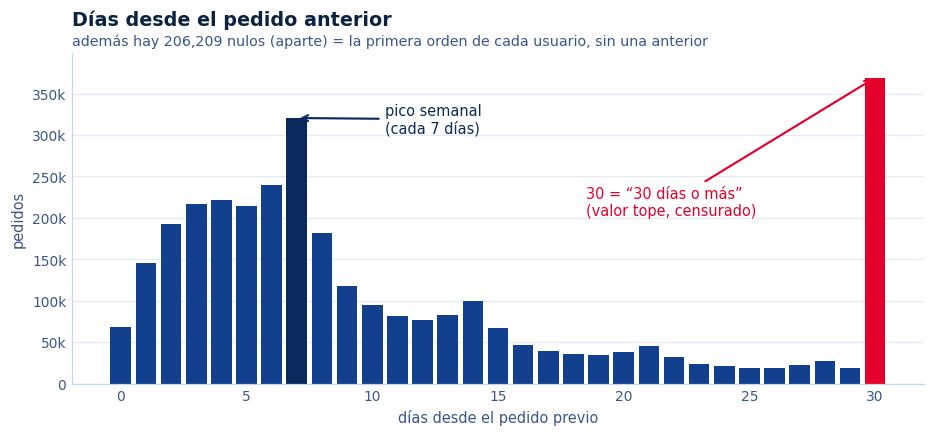

In [15]:
# Días desde el pedido anterior — con anotaciones que NO se tapan
vc = sql("""SELECT days_since_prior_order dias, COUNT(*) c FROM orders
            WHERE days_since_prior_order IS NOT NULL GROUP BY 1 ORDER BY 1""")
nulos = int(sql("SELECT COUNT(*) c FROM orders WHERE days_since_prior_order IS NULL")["c"][0])
c7  = int(vc.loc[vc.dias==7,  "c"].iloc[0])
c30 = int(vc.loc[vc.dias==30, "c"].iloc[0])
ymax = vc["c"].max()

fig, ax = plt.subplots(figsize=(10, 3.9))
cols = [ROJO if d==30 else (AZUL_OSC if d==7 else AZUL) for d in vc["dias"]]
ax.bar(vc["dias"], vc["c"], color=cols, width=.82)
ax.annotate("pico semanal\n(cada 7 días)", xy=(7, c7), xytext=(10.5, ymax*.82),
            ha="left", color=AZUL_OSC, fontsize=9.5,
            arrowprops=dict(arrowstyle="->", color=AZUL_OSC, lw=1.4))
ax.annotate("30 = “30 días o más”\n(valor tope, censurado)", xy=(30, c30), xytext=(18.5, ymax*.55),
            ha="left", color=ROJO, fontsize=9.5,
            arrowprops=dict(arrowstyle="->", color=ROJO, lw=1.4))
ax.set_ylim(0, ymax*1.08); ax.set_xticks(range(0,31,5))
ax.yaxis.set_major_formatter(FuncFormatter(miles))
ejes(ax, "Días desde el pedido anterior",
     f"además hay {nulos:,} nulos (aparte) = la primera orden de cada usuario, sin una anterior",
     xlab="días desde el pedido previo", ylab="pedidos")
guardar(fig, "08_recencia"); plt.show()

> **→ Cómo seguir**
>
> **Target = la última orden** de cada usuario; el historial es lo anterior. Hay **ritmo semanal**
> (pico claro a los 7 días y picos en `order_dow` 0–1) y franja **9–16 h**. Dos trampas de
> `days_since_prior_order`: los **nulos** son la primera orden → indicador **`es_primera_orden`**
> (no imputar); y el **30 está censurado** ("30 o más") → tratarlo como censura. `order_dow` no está
> documentado → **declarar el supuesto** de fin de semana.


## 8. Calidad que afecta la recomendación

*Solo los controles que cambian una decisión.*

In [16]:
dup = int(sql("SELECT COUNT(*)-COUNT(DISTINCT (order_id||'-'||product_id)) d FROM prior")["d"][0])
huerf = int(sql("""SELECT COUNT(*) c FROM (SELECT DISTINCT product_id FROM prior) x
                   LEFT JOIN products USING(product_id) WHERE products.product_id IS NULL""")["c"][0])
onmax = int(sql("SELECT MAX(order_number) m FROM orders")["m"][0])
calidad = pd.DataFrame([
 ["Integridad referencial (product_id huérfanos)", f"{huerf}", "OK — todo producto del historial existe en el catálogo"],
 ["Pares (orden, producto) duplicados", f"{dup}", "OK — la interacción usuario×producto es limpia"],
 ["order_number topeado", f"máx = {onmax}", "Techo del dataset (100), NO es outlier: documentar"],
 ["days_since_prior_order nulos", f"{nulos:,}", "1 por usuario (primera orden): indicador, no imputar"],
 ["days_since_prior_order censurado", "30 = '30+'", "Tratar como censura en features de recencia"],
 ["Usuarios test sin target", "75.000", "No evaluables; su historial sí entrena"],
 ["Productos nunca comprados", f"{nunca}", "Cold-start de ítem marginal"],
 ["Sesgo de popularidad", "80% compras ≈ 9% catálogo", "Medir cobertura junto con Recall@K"],
], columns=["control","resultado","decisión"])
calidad

,control,resultado,decisión
0,Integridad referencial (product_id huérfanos),0,OK — todo producto del historial existe en el ...
1,"Pares (orden, producto) duplicados",0,OK — la interacción usuario×producto es limpia
2,order_number topeado,máx = 100,"Techo del dataset (100), NO es outlier: docume..."
3,days_since_prior_order nulos,"206,209","1 por usuario (primera orden): indicador, no i..."
4,days_since_prior_order censurado,30 = '30+',Tratar como censura en features de recencia
5,Usuarios test sin target,75.000,No evaluables; su historial sí entrena
6,Productos nunca comprados,11,Cold-start de ítem marginal
7,Sesgo de popularidad,80% compras ≈ 9% catálogo,Medir cobertura junto con Recall@K


> **→ Cómo seguir**
>
> Claves limpias (0 huérfanos, 0 duplicados): **no hay limpieza pesada**. El trabajo de preparación
> es **conceptual** — indicador de primera orden, censura del 30, no recortar el techo de 100, no
> eliminar carritos grandes (normalizar por tamaño), declarar el supuesto de `order_dow`.


## 9. Síntesis — Cómo seguir (para la Daily 1 y la Demo)

| Pregunta | Decisión | Consecuencia para el modelo |
|---|---|---|
| **Tablas / unidad** | `orders`+`prior`=historial; catálogo aparte; `train`=target · unidad **usuario×producto** | Base analítica única y reproducible |
| **Evaluación** | Entrenar con `prior` (206.209); medir última orden de `train` (131.209); **sin split aleatorio** | Protocolo temporal, sin fuga |
| **A quién** | Nuevo 29% / Medio 39% / Heavy 32%; recompra 24%→62% | Cold-start para nuevos; recompra/CF para heavy |
| **Qué (popularidad)** | 50% compras ≈ 1,6% catálogo; top-10 nuevo vs heavy comparte 8/10 | Baseline de popularidad **difícil de batir** |
| **Categoría** | produce+dairy = 46% y son rutina (65–67%); pantry/personal care = descubrimiento (32–35%) | **Departamento/pasillo como feature** de contenido y cold-start |
| **Carrito** | ~8 ítems / ~5 deptos; posición 1→68% vs 20→48% de recompra | `add_to_cart_order` como feature; **el orden de las recs importa** |
| **Co-ocurrencia** | pares top = frescos; dominados por popularidad | Usar **lift/confianza**, no conteo crudo → modelo de complementos |
| **Cuándo** | ritmo semanal (7 días) + franja 9–16 h; `es_primera_orden` y censura del 30 | Features de recencia/periodicidad |
| **Baseline + métrica** | popularidad + repetir última orden · `Recall@10` **+ cobertura** por segmento | Detecta el modelo que solo repite éxitos |

**Riesgo #1 a comunicar en la Daily:** con este sesgo de popularidad, hay que medir **cobertura**,
no solo Recall — o le "ganamos" al baseline sin aportar valor de negocio.

---
*EDA reproducible · DuckDB + pandas · figuras en `figuras/` para la Demo.*


In [17]:
con.close()
print("Listo. Figuras exportadas en:", FIG.resolve())

Listo. Figuras exportadas en: C:\dev\instacart-recommender\reports\figures
